# Analysis and Tokenization 

This notebook picks up where notebook 01 left off. It loads the cleaned data and does two things:

Part A: compute statistics and generate plots to understand the dataset
Part B: train BPE tokenizers using SentencePiece and encode all splits into subwords

By the end of this notebook, we have everything needed to start training the Transformer model.


## Part A — Statistics and Plots


### 1. Setup


In [42]:
from pathlib import Path
from collections import Counter
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sentencepiece as spm

sns.set_theme(style='whitegrid')
%matplotlib inline

print('Imports loaded successfully')


Imports loaded successfully


### 2. Load Cleaned Data

We load the Parquet files saved by notebook 01.


In [43]:
dfs = {}
for split in ['train','validation','test']:
    dfs[split] = pd.read_parquet(f'../data/processed/{split}_clean.parquet')
all_df = pd.read_parquet('../data/processed/all_clean.parquet')

for split, df in dfs.items():
    print(f'{split:12s} : {df.shape}')
print(f'all_df       : {all_df.shape}')


train        : (50000, 6)
validation   : (888, 6)
test         : (8567, 6)
all_df       : (59455, 6)


### 3. Preview Data


In [44]:
for split, df in dfs.items():
    print(f'--- {split} ---')
    print(f'Lines: {len(df):,}')
    print('Arabic :', df['source_ar'].iloc[0][:80])
    print('English:', df['target_en'].iloc[0][:80])
    print()


--- train ---
Lines: 50,000
Arabic : اذاً نحن نبيعها، ثم شئ غريب كان يحصل مع المكتبات. المكتبة، في الواقع-- رغماً عن 
English: so we sell 'em, and then something weird had been happening with the stores. the

--- validation ---
Lines: 888
Arabic : السنة الماضية عرضت هاتين الشريحتين لكي اوضح ان الغطاء الجليدي القطبي، الذي كان خ
English: last year i showed these two slides so that demonstrate that the arctic ice cap,

--- test ---
Lines: 8,567
Arabic : قبل عدة سنوات، هنا في تيد، قدّم بيتر سكيلمان منافسة تصميم تسمي منافسة حلوي المار
English: several years ago here at ted, peter skillman introduced a design challenge call



### 4. Compute Statistics


In [45]:
rows = []
for split, df in dfs.items():
    src_tokens = [t for sent in df['source_ar'].astype(str) for t in sent.split()]
    tgt_tokens = [t for sent in df['target_en'].astype(str) for t in sent.split()]
    tgt_len = df['target_en'].astype(str).apply(lambda x: len(x.split()))
    rows.append({'split':split,'pairs':len(df),
        'avg_src':round(df['source_len'].mean(),2),'avg_tgt':round(tgt_len.mean(),2),
        'max_src':df['source_len'].max(),'max_tgt':tgt_len.max(),
        'unique_src':len(set(src_tokens)),'unique_tgt':len(set(tgt_tokens))})
stats_df = pd.DataFrame(rows)
print(stats_df.to_string())


        split  pairs  avg_src  avg_tgt  max_src  max_tgt  unique_src  unique_tgt
0       train  50000    14.42    17.45       80       80      112380       56560
1  validation    888    15.45    19.58       66       77        6022        4203
2        test   8567    13.84    16.74       77       78       30858       17584


### 5. Basic Plots

Sentence counts, total tokens, and average lengths side by side.


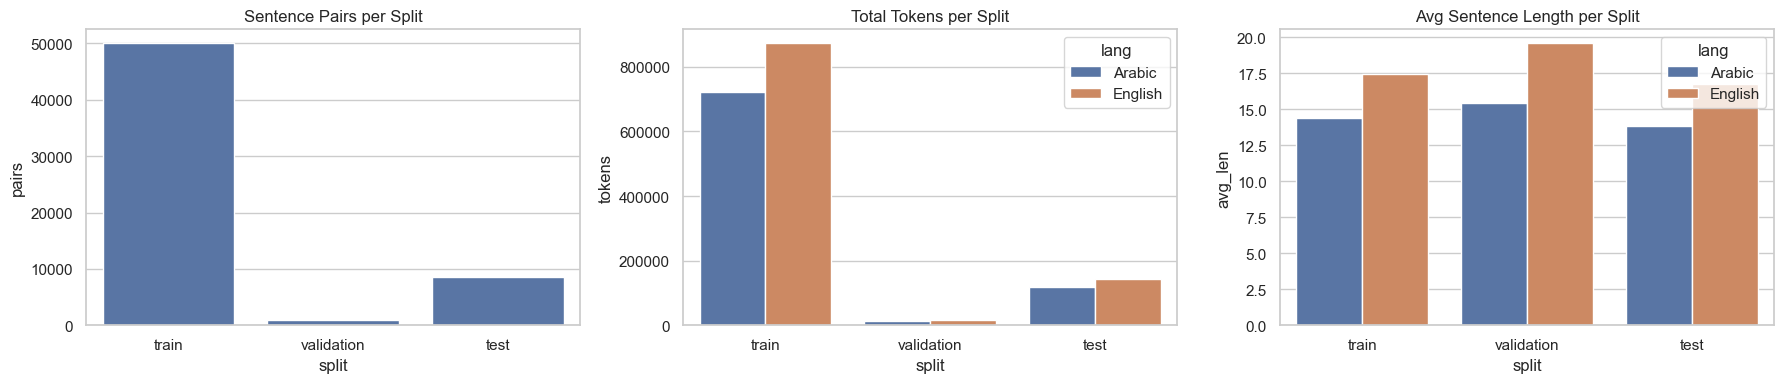

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Sentence counts
sns.barplot(x='split', y='pairs', data=stats_df, ax=axes[0])
axes[0].set_title('Sentence Pairs per Split')

# Total tokens
tok_rows = []
for _, r in stats_df.iterrows():
    tok_rows.append({'split':r['split'],'lang':'Arabic','tokens':r['avg_src']*r['pairs']})
    tok_rows.append({'split':r['split'],'lang':'English','tokens':r['avg_tgt']*r['pairs']})
sns.barplot(x='split', y='tokens', hue='lang', data=pd.DataFrame(tok_rows), ax=axes[1])
axes[1].set_title('Total Tokens per Split')

# Average lengths
avg_rows = []
for _, r in stats_df.iterrows():
    avg_rows.append({'split':r['split'],'lang':'Arabic','avg_len':r['avg_src']})
    avg_rows.append({'split':r['split'],'lang':'English','avg_len':r['avg_tgt']})
sns.barplot(x='split', y='avg_len', hue='lang', data=pd.DataFrame(avg_rows), ax=axes[2])
axes[2].set_title('Avg Sentence Length per Split')

plt.tight_layout()
plt.show()


### 6. Length Distributions

Arabic and English histograms side by side for each split so you can compare them.


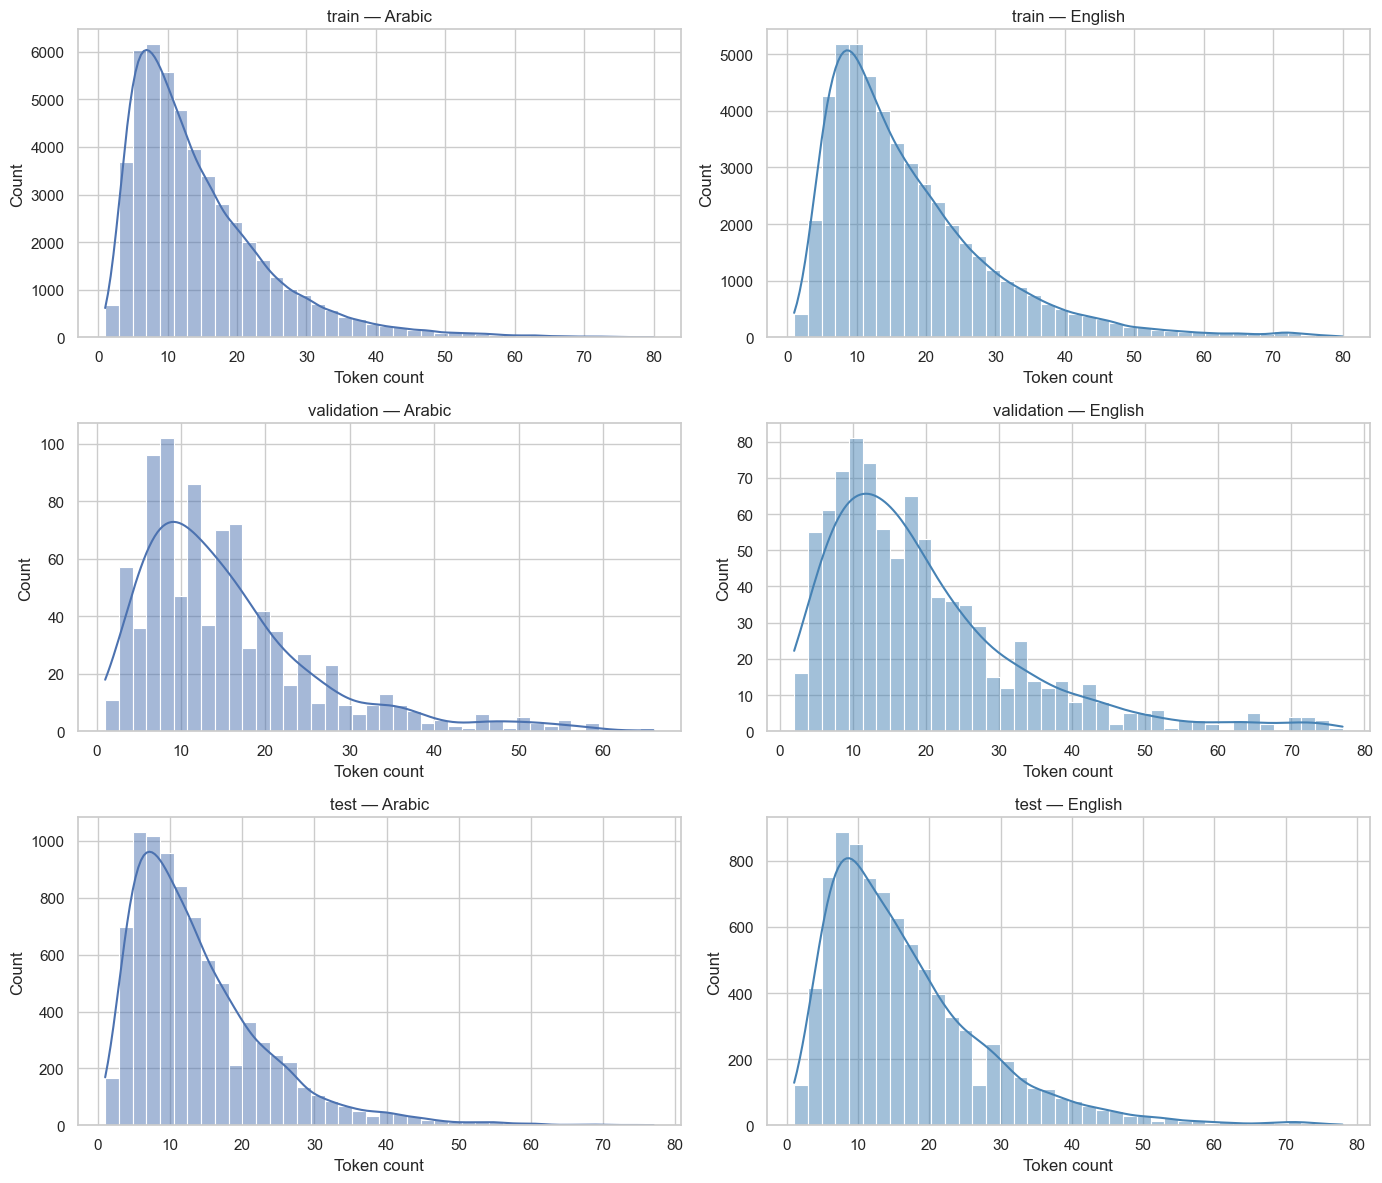

In [47]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, split in enumerate(['train','validation','test']):
    df = dfs[split]
    tgt_len = df['target_en'].astype(str).apply(lambda x: len(x.split()))

    sns.histplot(df['source_len'], bins=40, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{split} — Arabic')
    axes[i, 0].set_xlabel('Token count')

    sns.histplot(tgt_len, bins=40, kde=True, color='steelblue', ax=axes[i, 1])
    axes[i, 1].set_title(f'{split} — English')
    axes[i, 1].set_xlabel('Token count')

plt.tight_layout()
plt.show()


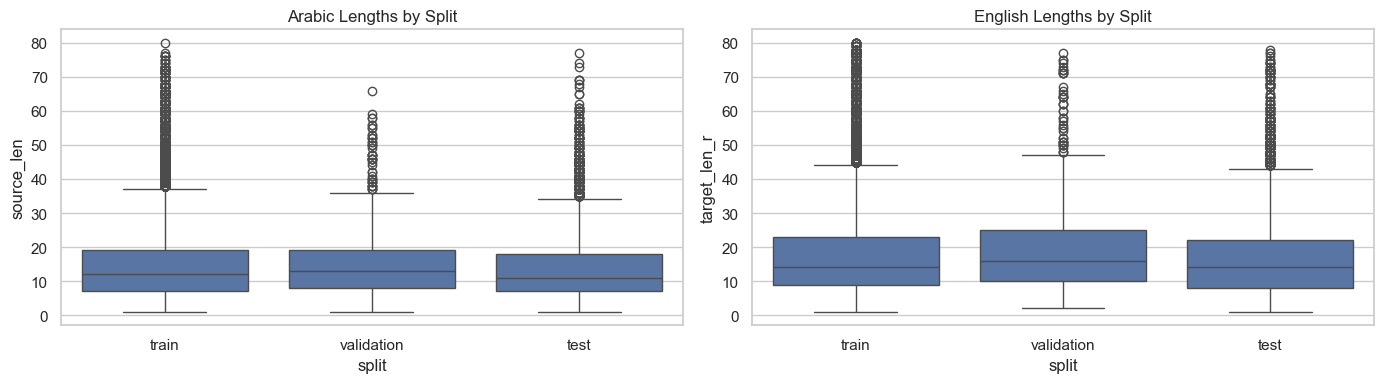

In [48]:
all_df['target_len_r'] = all_df['target_en'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x='split', y='source_len', data=all_df, ax=axes[0])
axes[0].set_title('Arabic Lengths by Split')
sns.boxplot(x='split', y='target_len_r', data=all_df, ax=axes[1])
axes[1].set_title('English Lengths by Split')
plt.tight_layout()
plt.show()


### 7. Quality Check Plots

Source vs target length scatter and ratio distribution for each split.


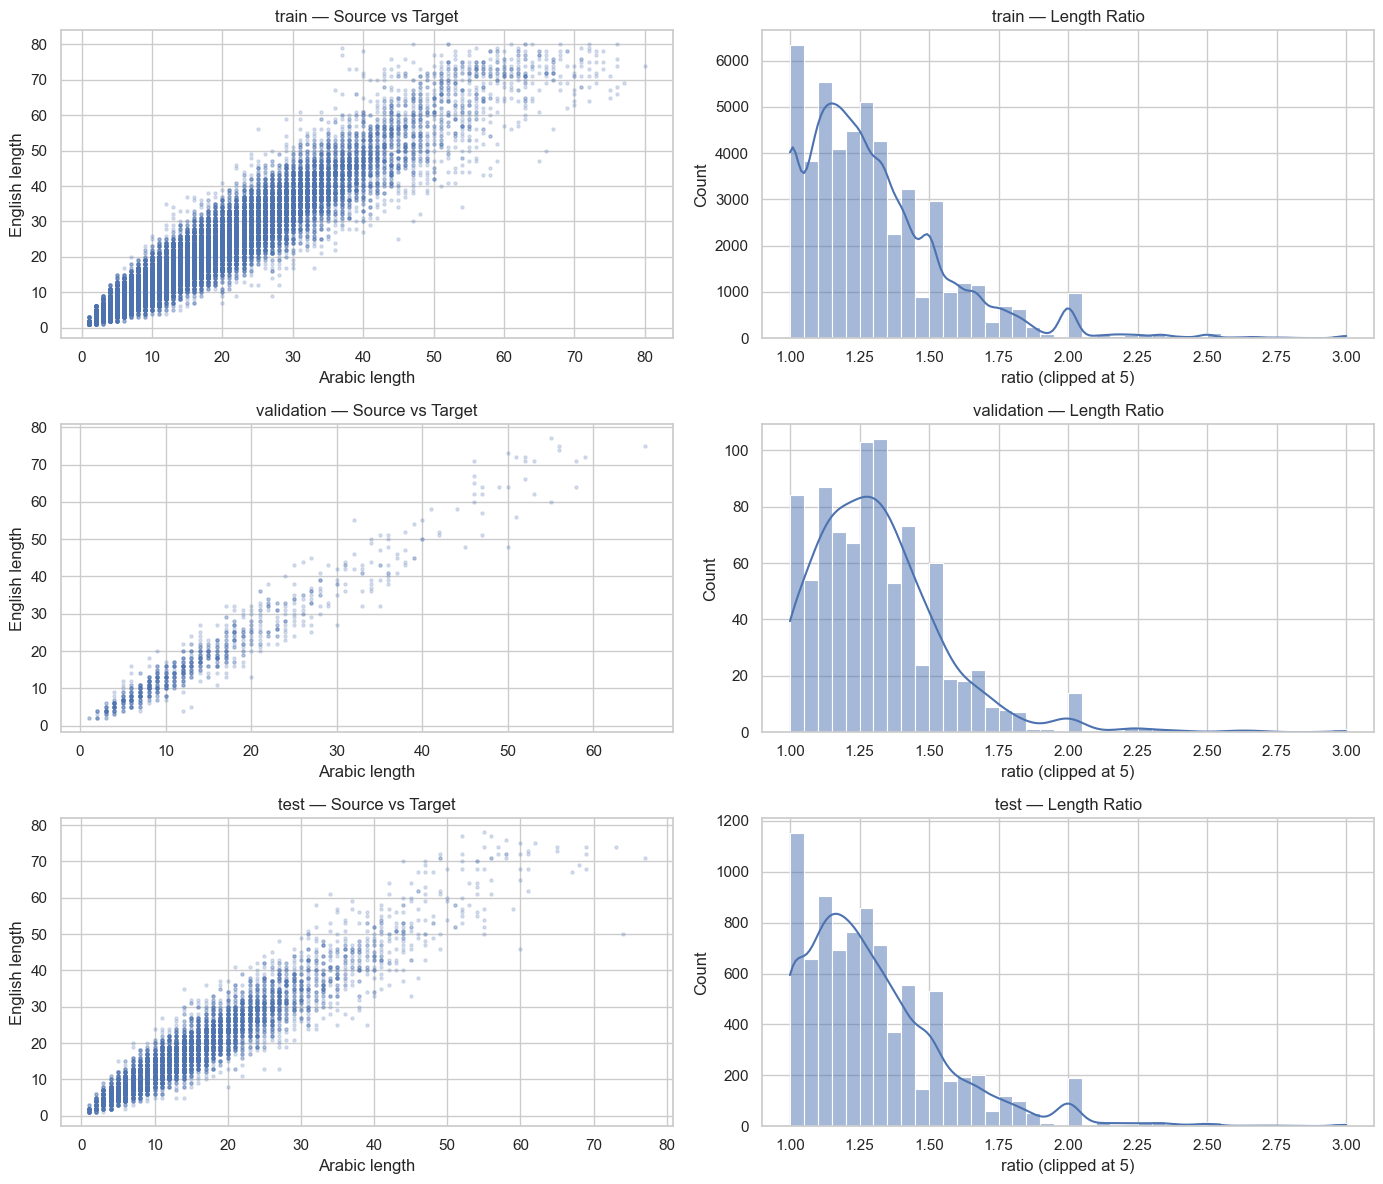

In [49]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, split in enumerate(['train','validation','test']):
    df = dfs[split]
    tgt_len = df['target_en'].astype(str).apply(lambda x: len(x.split()))

    axes[i, 0].scatter(df['source_len'], tgt_len, alpha=0.2, s=5)
    axes[i, 0].set_xlabel('Arabic length')
    axes[i, 0].set_ylabel('English length')
    axes[i, 0].set_title(f'{split} — Source vs Target')

    sns.histplot(df['length_ratio'].clip(upper=5), bins=40, kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f'{split} — Length Ratio')
    axes[i, 1].set_xlabel('ratio (clipped at 5)')

plt.tight_layout()
plt.show()


### 8. Vocabulary Plots

Unique token counts and the most frequent tokens in the training set.


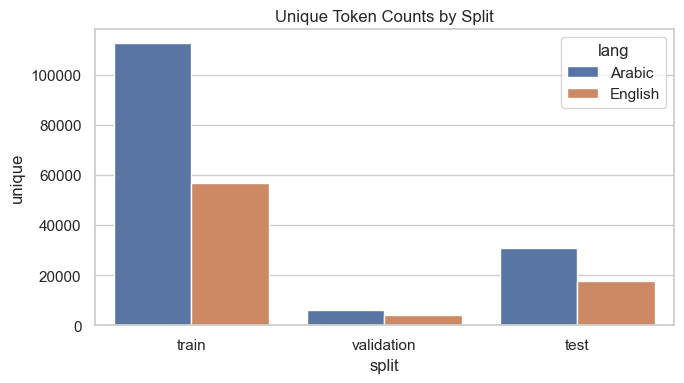

In [50]:
vocab_rows = []
for _, r in stats_df.iterrows():
    vocab_rows.append({'split':r['split'],'lang':'Arabic','unique':r['unique_src']})
    vocab_rows.append({'split':r['split'],'lang':'English','unique':r['unique_tgt']})
plt.figure(figsize=(7,4))
sns.barplot(x='split', y='unique', hue='lang', data=pd.DataFrame(vocab_rows))
plt.title('Unique Token Counts by Split')
plt.tight_layout()
plt.show()


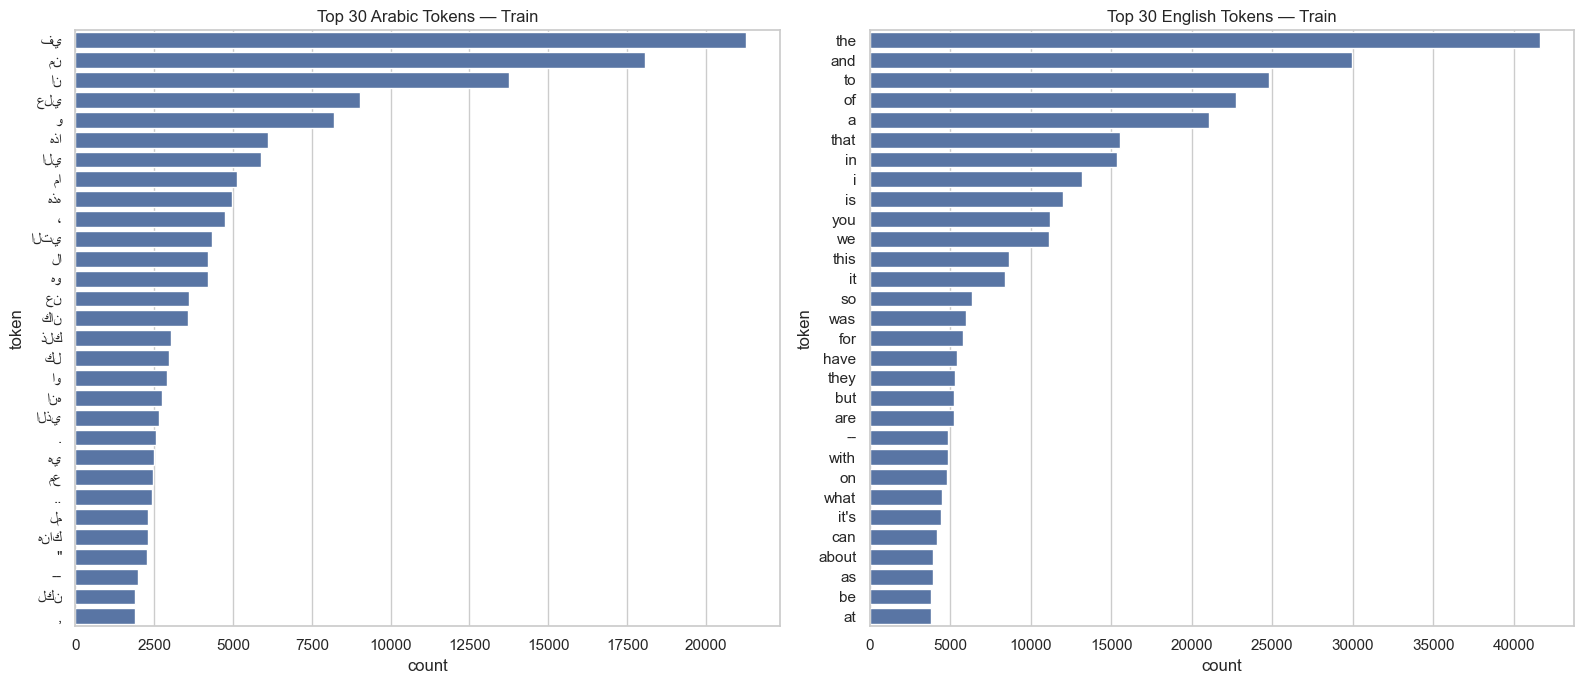

In [51]:
# Top 30 tokens — Arabic vs English side by side
ar_tokens = [t for sent in dfs['train']['source_ar'].astype(str) for t in sent.split()]
ar_top30 = pd.DataFrame(Counter(ar_tokens).most_common(30), columns=['token','count'])
en_tokens = [t for sent in dfs['train']['target_en'].astype(str) for t in sent.split()]
en_top30 = pd.DataFrame(Counter(en_tokens).most_common(30), columns=['token','count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(x='count', y='token', data=ar_top30, ax=axes[0])
axes[0].set_title('Top 30 Arabic Tokens — Train')
sns.barplot(x='count', y='token', data=en_top30, ax=axes[1])
axes[1].set_title('Top 30 English Tokens — Train')
plt.tight_layout()
plt.show()


---

## Part B — BPE Tokenization

Now we train BPE tokenizers using SentencePiece. BPE splits words into subword units,
which helps the model handle rare words by breaking them into known pieces.

We train separate models for Arabic and English because the scripts are completely different.
Vocab size is 8,000 each, which is appropriate for 50k low-resource pairs.
We only train on the training set. Validation and test are encoded but never seen by the tokenizer.


### 9. Tokenization Constants


In [52]:
VOCAB_SIZE_AR = 8000
VOCAB_SIZE_EN = 8000
MODEL_TYPE    = 'bpe'

CLEAN_DIR     = Path('../data/clean')
TOKENIZED_DIR = Path('../data/tokenized')
VOCAB_DIR     = Path('../data/vocab')
SPLITS        = ['train', 'validation', 'test']

for d in [TOKENIZED_DIR, VOCAB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Vocab size AR : {VOCAB_SIZE_AR}')
print(f'Vocab size EN : {VOCAB_SIZE_EN}')


Vocab size AR : 8000
Vocab size EN : 8000


### 10. Train SentencePiece Models

Character coverage is 0.9995 for Arabic and 1.0 for English.


In [53]:
# Train Arabic BPE model
spm.SentencePieceTrainer.train(
    input=str(CLEAN_DIR / 'train.ar'),
    model_prefix=str(VOCAB_DIR / 'sp_ar'),
    vocab_size=VOCAB_SIZE_AR, model_type=MODEL_TYPE,
    character_coverage=0.9995,
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
    pad_piece='<pad>', unk_piece='<unk>', bos_piece='<s>', eos_piece='</s>',
    input_sentence_size=50000, shuffle_input_sentence=True,
)
print(f'Saved: {VOCAB_DIR}/sp_ar.model')


Saved: ..\data\vocab/sp_ar.model


In [54]:
# Train English BPE model
spm.SentencePieceTrainer.train(
    input=str(CLEAN_DIR / 'train.en'),
    model_prefix=str(VOCAB_DIR / 'sp_en'),
    vocab_size=VOCAB_SIZE_EN, model_type=MODEL_TYPE,
    character_coverage=1.0,
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
    pad_piece='<pad>', unk_piece='<unk>', bos_piece='<s>', eos_piece='</s>',
    input_sentence_size=50000, shuffle_input_sentence=True,
)
print(f'Saved: {VOCAB_DIR}/sp_en.model')


Saved: ..\data\vocab/sp_en.model


### 11. Load Models and Preview


In [55]:
sp_ar = spm.SentencePieceProcessor()
sp_ar.load(str(VOCAB_DIR / 'sp_ar.model'))
sp_en = spm.SentencePieceProcessor()
sp_en.load(str(VOCAB_DIR / 'sp_en.model'))

print(f'Arabic vocab size  : {sp_ar.get_piece_size()}')
print(f'English vocab size : {sp_en.get_piece_size()}')


Arabic vocab size  : 8000
English vocab size : 8000


In [56]:
# Arabic tokenization examples
with open(CLEAN_DIR / 'train.ar', 'r', encoding='utf-8') as f:
    ar_examples = [f.readline().strip() for _ in range(5)]

for sent in ar_examples:
    pieces = sp_ar.encode(sent, out_type=str)
    print(f'Original : {sent}')
    print(f'BPE ({len(pieces):2d}): {" ".join(pieces)}')
    print()


Original : اذاً نحن نبيعها، ثم شئ غريب كان يحصل مع المكتبات. المكتبة، في الواقع-- رغماً عن اننا بداناها كمجرد هفوة -- المكتبة في الواقع جنت اموالاً.
BPE (43): ▁اذاً ▁نحن ▁ن بي عها ، ▁ثم ▁شئ ▁غريب ▁كان ▁يحصل ▁مع ▁المكت بات . ▁المكت بة ، ▁في ▁الواقع -- ▁رغ ماً ▁عن ▁اننا ▁بدا ناها ▁ك مج رد ▁ه ف وة ▁-- ▁المكت بة ▁في ▁الواقع ▁ج نت ▁اموال اً .

Original : لربما كانت المشكلة في الافتراض الاساسي ان كل الادمغة مصنوعة بنفس الطريقة.
BPE (16): ▁لربما ▁كانت ▁المشكلة ▁في ▁الافت راض ▁الاساسي ▁ان ▁كل ▁الا دم غة ▁مصنوعة ▁بنفس ▁الطريقة .

Original : لكن خمنوا ماذا، لا احد في الواقع يهتم.
BPE (12): ▁لكن ▁خ من وا ▁ماذا ، ▁لا ▁احد ▁في ▁الواقع ▁يهتم .

Original : ثيلما نيكولس: انا السجينة رقم 0B2472
BPE (18): ▁ث يل ما ▁نيك ول س : ▁انا ▁السج ينة ▁رقم ▁ 0 B 2 4 7 2

Original : لو رجعتم الي الوراء لبضع مئات من السنين, كان العالم باكمله مجتمع منغلق جداً
BPE (19): ▁لو ▁رج عتم ▁الي ▁الوراء ▁لب ضع ▁مئات ▁من ▁السنين , ▁كان ▁العالم ▁باكمله ▁مجتمع ▁من غ لق ▁جداً



In [57]:
# English tokenization examples
with open(CLEAN_DIR / 'train.en', 'r', encoding='utf-8') as f:
    en_examples = [f.readline().strip() for _ in range(5)]

for sent in en_examples:
    pieces = sp_en.encode(sent, out_type=str)
    print(f'Original : {sent}')
    print(f'BPE ({len(pieces):2d}): {" ".join(pieces)}')
    print()


Original : so we sell 'em, and then something weird had been happening with the stores. the store, actually -- even though we started out as just a gag -- the store actually made money.
BPE (40): ▁so ▁we ▁sell ▁' em , ▁and ▁then ▁something ▁weird ▁had ▁been ▁happening ▁with ▁the ▁store s . ▁the ▁store , ▁actually ▁-- ▁even ▁though ▁we ▁started ▁out ▁as ▁just ▁a ▁g ag ▁-- ▁the ▁store ▁actually ▁made ▁money .

Original : maybe the problem was with the basic assumption that all brains are made in the same way.
BPE (18): ▁maybe ▁the ▁problem ▁was ▁with ▁the ▁basic ▁assumption ▁that ▁all ▁brains ▁are ▁made ▁in ▁the ▁same ▁way .

Original : but guess what, nobody will really care.
BPE ( 9): ▁but ▁guess ▁what , ▁nobody ▁will ▁really ▁care .

Original : thelma nichols: inmate number 0b2472.
BPE (18): ▁the l ma ▁nich ol s : ▁in m ate ▁number ▁ 0 b 2 4 7 2.

Original : if you go back a few hundred years, all around the world it was a very closed society.
BPE (20): ▁if ▁you ▁go ▁back ▁a ▁few ▁hun

### 12. Roundtrip Verification

Encode then decode must recover the original text exactly.


In [58]:
all_ok = True
for sent in ar_examples[:3] + en_examples[:3]:
    model = sp_ar if sent in ar_examples else sp_en
    ids = model.encode(sent, out_type=int)
    decoded = model.decode(ids)
    match = decoded.strip() == sent.strip()
    if not match: all_ok = False
    print(f'Match={match}  |  {sent[:60]}...')

print()
print('All roundtrip checks passed.' if all_ok else 'WARNING: Some failed!')


Match=True  |  اذاً نحن نبيعها، ثم شئ غريب كان يحصل مع المكتبات. المكتبة، ف...
Match=True  |  لربما كانت المشكلة في الافتراض الاساسي ان كل الادمغة مصنوعة ...
Match=True  |  لكن خمنوا ماذا، لا احد في الواقع يهتم....
Match=True  |  so we sell 'em, and then something weird had been happening ...
Match=True  |  maybe the problem was with the basic assumption that all bra...
Match=True  |  but guess what, nobody will really care....

All roundtrip checks passed.


### 13. Encode All Splits

Apply the trained BPE models to produce tokenized files.


In [59]:
def encode_file(sp_model, input_path, output_path):
    count = 0
    with open(input_path, 'r', encoding='utf-8') as fin, \
         open(output_path, 'w', encoding='utf-8') as fout:
        for line in fin:
            pieces = sp_model.encode(line.strip(), out_type=str)
            fout.write(' '.join(pieces) + '\n')
            count += 1
    return count

for split in SPLITS:
    for lang, model in [('ar', sp_ar), ('en', sp_en)]:
        n = encode_file(model, CLEAN_DIR/f'{split}.{lang}', TOKENIZED_DIR/f'{split}.{lang}.bpe')
        print(f'Encoded {n:>6,} lines: {split}.{lang}.bpe')


Encoded 50,000 lines: train.ar.bpe
Encoded 50,000 lines: train.en.bpe
Encoded    888 lines: validation.ar.bpe
Encoded    888 lines: validation.en.bpe
Encoded  8,567 lines: test.ar.bpe
Encoded  8,567 lines: test.en.bpe


In [60]:
# Verify line counts
all_ok = True
for split in SPLITS:
    for lang in ['ar', 'en']:
        with open(CLEAN_DIR / f'{split}.{lang}') as f: n_clean = sum(1 for _ in f)
        with open(TOKENIZED_DIR / f'{split}.{lang}.bpe') as f: n_bpe = sum(1 for _ in f)
        ok = n_clean == n_bpe
        if not ok: all_ok = False
        print(f'{split}.{lang}: clean={n_clean:,}  bpe={n_bpe:,}  match={ok}')

print('\nAll line counts match.' if all_ok else '\nWARNING: mismatch!')


train.ar: clean=50,000  bpe=50,000  match=True
train.en: clean=50,000  bpe=50,000  match=True
validation.ar: clean=888  bpe=888  match=True
validation.en: clean=888  bpe=888  match=True
test.ar: clean=8,567  bpe=8,567  match=True
test.en: clean=8,567  bpe=8,567  match=True

All line counts match.


### 14. Tokenization Statistics

Compare whitespace token counts vs BPE subword counts.


In [61]:
rows = []
for split in SPLITS:
    for lang, label in [('ar', 'Arabic'), ('en', 'English')]:
        with open(CLEAN_DIR / f'{split}.{lang}') as f:
            ws = [len(line.split()) for line in f]
        with open(TOKENIZED_DIR / f'{split}.{lang}.bpe') as f:
            bpe = [len(line.split()) for line in f]
        ws_arr, bpe_arr = np.array(ws), np.array(bpe)
        rows.append({'split':split,'language':label,
            'ws_tokens':int(ws_arr.sum()),'bpe_tokens':int(bpe_arr.sum()),
            'avg_ws':round(ws_arr.mean(),2),'avg_bpe':round(bpe_arr.mean(),2),
            'expansion':round(bpe_arr.sum()/max(ws_arr.sum(),1),3)})
tok_stats = pd.DataFrame(rows)
print(tok_stats.to_string(index=False))


     split language  ws_tokens  bpe_tokens  avg_ws  avg_bpe  expansion
     train   Arabic     720822     1082196   14.42    21.64      1.501
     train  English     872722     1162238   17.45    23.24      1.332
validation   Arabic      13724       20991   15.45    23.64      1.530
validation  English      17386       23138   19.58    26.06      1.331
      test   Arabic     118560      178508   13.84    20.84      1.506
      test  English     143437      190795   16.74    22.27      1.330


### 15. Tokenization Plots

BPE subword length distributions, expansion ratio, and top subwords — Arabic vs English.


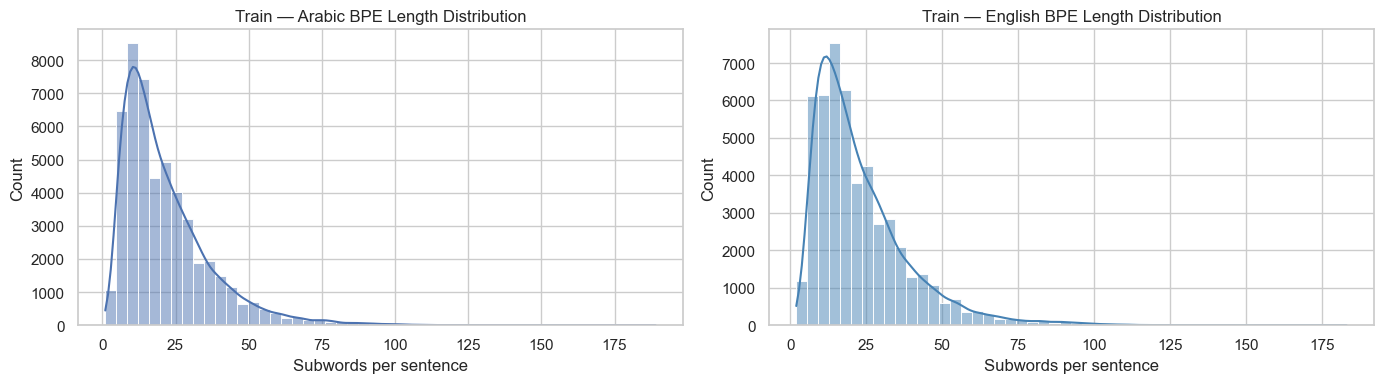

In [62]:
# Subword length distributions — Arabic vs English side by side
with open(TOKENIZED_DIR / 'train.ar.bpe') as f:
    ar_lengths = [len(line.split()) for line in f]
with open(TOKENIZED_DIR / 'train.en.bpe') as f:
    en_lengths = [len(line.split()) for line in f]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(ar_lengths, bins=50, kde=True, ax=axes[0])
axes[0].set_title('Train — Arabic BPE Length Distribution')
axes[0].set_xlabel('Subwords per sentence')
sns.histplot(en_lengths, bins=50, kde=True, color='steelblue', ax=axes[1])
axes[1].set_title('Train — English BPE Length Distribution')
axes[1].set_xlabel('Subwords per sentence')
plt.tight_layout()
plt.show()


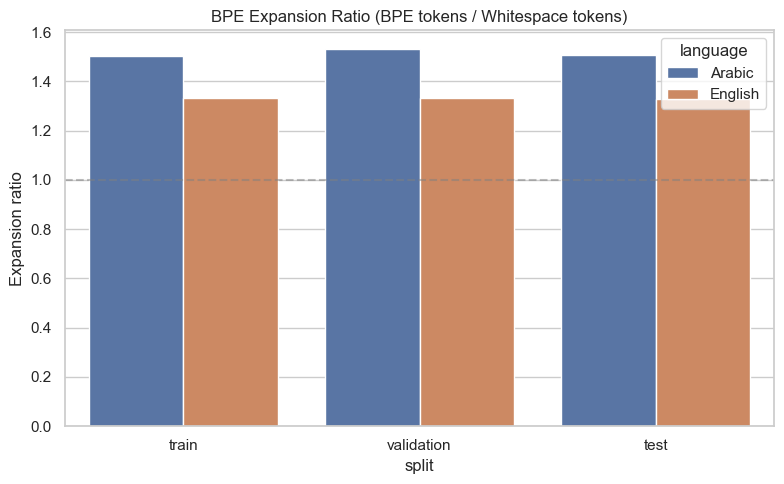

In [63]:
# Expansion ratio comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='split', y='expansion', hue='language', data=tok_stats)
plt.title('BPE Expansion Ratio (BPE tokens / Whitespace tokens)')
plt.ylabel('Expansion ratio')
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


C:\Users\Ahmed\AppData\Local\Temp\ipykernel_38188\1509683127.py:15: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Ahmed\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


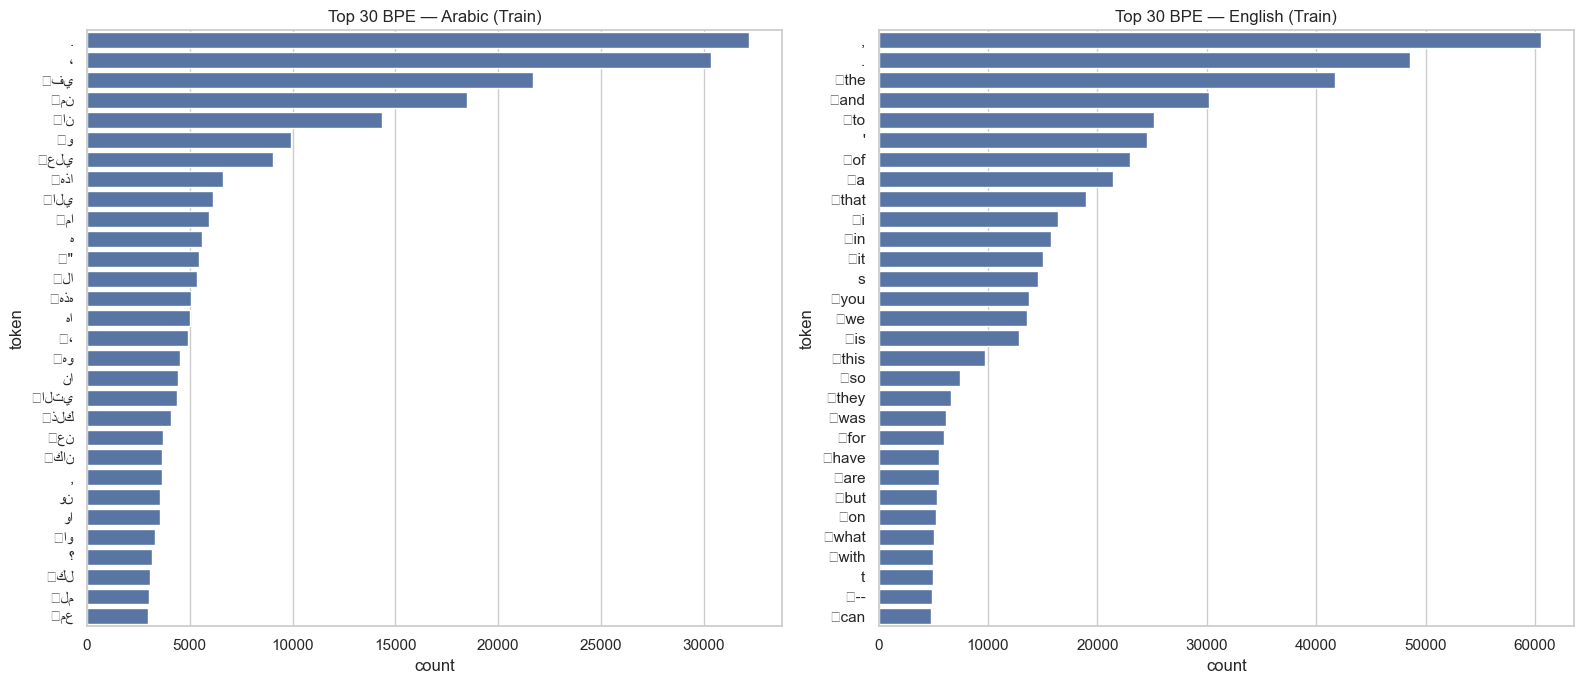


Done — Notebook 02 completed successfully.


In [ ]:
# Top 30 BPE subwords — Arabic vs English side by side
with open(TOKENIZED_DIR / 'train.ar.bpe') as f:
    ar_bpe = [t for line in f for t in line.split()]
with open(TOKENIZED_DIR / 'train.en.bpe') as f:
    en_bpe = [t for line in f for t in line.split()]

ar_top = pd.DataFrame(Counter(ar_bpe).most_common(30), columns=['token','count'])
en_top = pd.DataFrame(Counter(en_bpe).most_common(30), columns=['token','count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(x='count', y='token', data=ar_top, ax=axes[0])
axes[0].set_title('Top 30 BPE — Arabic (Train)')
sns.barplot(x='count', y='token', data=en_top, ax=axes[1])
axes[1].set_title('Top 30 BPE — English (Train)')
plt.tight_layout()
plt.show()
